In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import functions
import tensorflow as tf

I0000 00:00:1786289202.733165    2640 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786289202.738394    2640 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786289203.235643    2640 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786289205.731119    2640 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Load data

In [2]:
# list files
os.listdir()

crbn_binding_data = pd.read_excel('mmc3.xlsx', skiprows=1)
crbn_binding_data.head()

,Cxsmiles,Smiles,Catalog ID,"V, µL","Conc, mM",Formula,MW,Purity,Salt smiles,Salt_name,...,"Stereochem,data","Geometric,isomer",Chemical name,ClogP,logS,HBD,HBA,TPSA,RotBonds,FP Response
0,CC1(C)CC(=O)NC=2C=CC(=CC21)S(=O)(=O)NC=3C=CC=4...,CC1(C)CC(=O)NC=2C=CC(=CC21)S(=O)(=O)NC=3C=CC=4...,Z5000147527,10,10,C24H24N4O6S,496.5356,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",1.614,-4.421,3,6,141.75,3,63.85
1,CCN1N=CC=C1S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C2)C4C...,CCN1N=CC=C1S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C2)C4C...,Z5000147208,10,10,C18H19N5O5S,417.4390,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",0.024,-3.102,2,6,130.47,4,65.80
2,CC=1C=CC(=C2C=CC=CC12)S(=O)(=O)NC=3C=CC=4C(=O)...,CC=1C=CC(=C2C=CC=CC12)S(=O)(=O)NC=3C=CC=4C(=O)...,Z5000146412,10,10,C24H21N3O5S,463.5056,96.81,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",2.773,-6.251,2,5,112.65,3,60.35
3,O=C1N(CC=2C=C(NS(=O)(=O)C3=C(C#N)SC=4C=CC=CC34...,O=C1N(CC=2C=C(NS(=O)(=O)C3=C(C#N)SC=4C=CC=CC34...,Z5000147289,10,10,C22H16N4O5S2,480.5162,98.53,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"2-cyano-N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2...",2.107,-5.659,2,6,136.44,3,64.70
4,CCCC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C...,CCCC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C...,Z5000145522,10,10,C22H23N3O5S,441.5001,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",2.657,-5.483,2,5,112.65,5,61.15


## Exploration

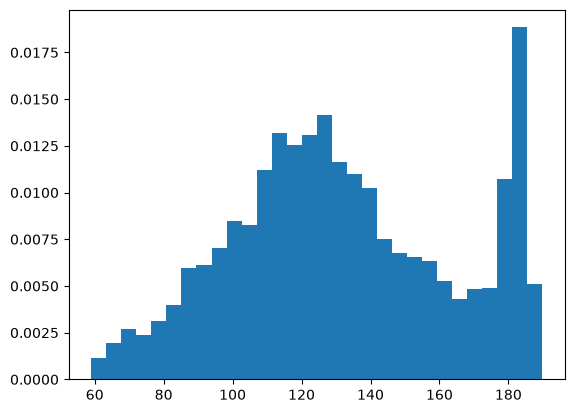

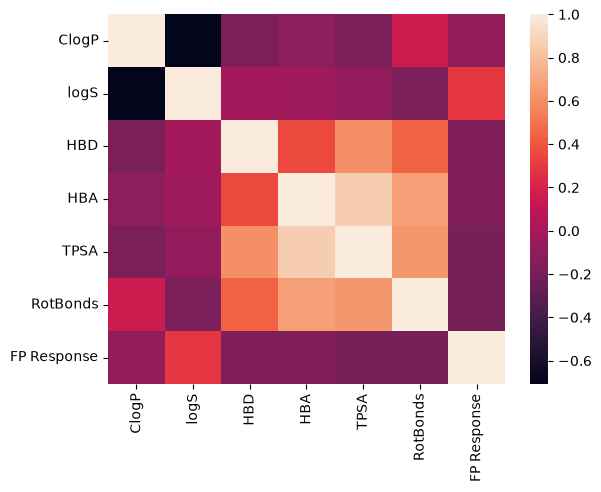

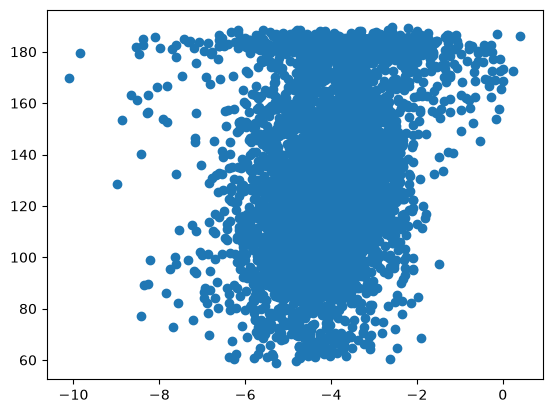

In [6]:
crbn_binding_data.dtypes
plt.hist(crbn_binding_data['FP Response'], density=True, bins=30)
plt.show()
corr = crbn_binding_data.loc[:, "ClogP":"FP Response"].corr()
sns.heatmap(corr) 
plt.show()

# there seems to be small correlation between FP response and logS
reg = linregress(crbn_binding_data["logS"], crbn_binding_data["FP Response"])
plt.scatter(crbn_binding_data["logS"], crbn_binding_data["FP Response"])
plt.show()

## Transform smiles to fingerprints (Morgan, radius 2, n_bits 2048)

In [7]:
# visualize firt smile
s = crbn_binding_data["Smiles"][1]
m = Chem.MolFromSmiles(s)
Draw.MolToImage(m)

# convert to fingerprints

morgan_gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp_list(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * 2048
    fp = morgan_gen.GetFingerprint(mol)
    return(list(fp))

ai_data = pd.DataFrame(crbn_binding_data["Smiles"].apply(smiles_to_fp_list).tolist())
ai_data = pd.concat([ai_data, crbn_binding_data[["Catalog ID", "FP Response"]].rename(columns={"Catalog ID": "id", "FP Response": "binding"}) ], axis=1)
ai_data.head()

,0,1,2,3,4,5,6,7,8,9,...,2040,2041,2042,2043,2044,2045,2046,2047,id,binding
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147527,63.85
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147208,65.80
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000146412,60.35
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147289,64.70
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000145522,61.15


## Split data (80% train test split)

In [8]:
X = ai_data.iloc[:, :-2]
y = ai_data["binding"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Classical Machine Learning

### Random Forest


#### Training

In [9]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

#### Prediction

In [ ]:
y_pred = model_rf.predict(X_test)

#### Visualization

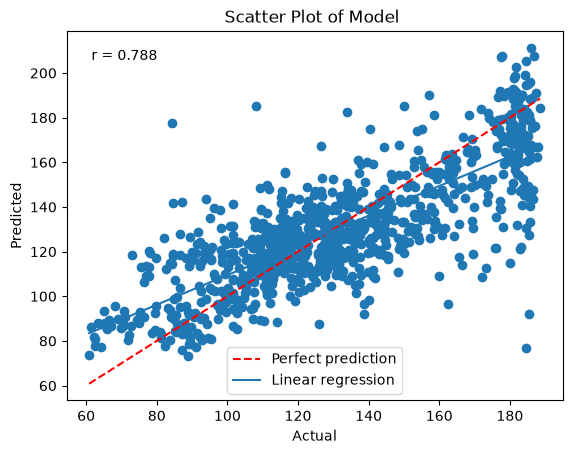

In [63]:
functions.scatter_plot_fn(y_test, y_pred)

### Lasso

### XGboost

https://gist.github.com/pb111/cc341409081dffa5e9eaf60d79562a03

## Deep learning

#### training

In [31]:
X_train.shape

(3584, 2048)

In [59]:
model = tf.keras.Sequential([
    tf.keras.Input(shape = (2048, )),
    tf.keras.layers.Dense(units = 64, activation = 'relu'),
    tf.keras.layers.Dense(units = 64, activation = 'relu'),
    tf.keras.layers.Dense(units = 64, activation = 'relu'),
    tf.keras.layers.Dense(units=1)
])

In [60]:
model.compile(loss = "mean_squared_error", optimizer=tf.keras.optimizers.Adam(
         learning_rate=0.0001,
        clipnorm=1.0
))

In [ ]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 360.2990
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 330.6268
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 306.1194
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 285.8596
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 269.3481
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 255.8323
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 243.6104
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 232.5143
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 222.0147
Epoch 10/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 213.7222
Epoch 11/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 205.1558
Epoch 12/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 197.0802
Epoch 13/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 189.5702
Epoch 14/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 182.5109
Epoch 15/100
11

In [64]:
y_pred = model.predict(X_test).flatten()

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


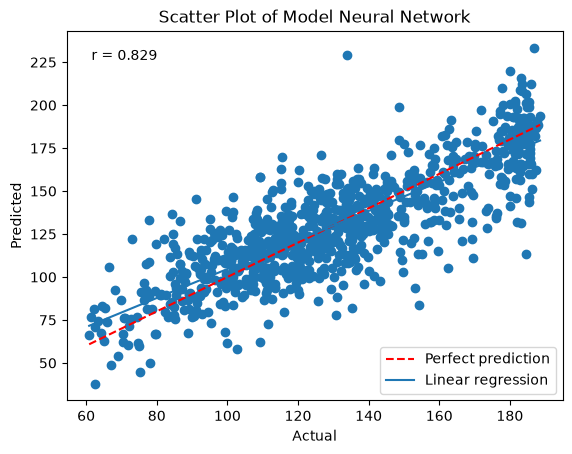

In [65]:
functions.scatter_plot_fn(y_test, y_pred, "Neural Network")